# Kelp2 - UAS PBA: Named Entity Recognition ABSA

Notebook ini mengerjakan **Proyek B - Named Entity Recognition (NER) ABSA**.  
Tujuannya adalah mengenali span/token yang merujuk pada aspek ABSA di dalam review Google Places, seperti produk, harga, tempat, promosi, dan out-of-topic.

Notebook dibuat bertahap seperti guided notebook:
1. data loading JSONL,
2. validasi token-label dan format BIO,
3. konversi tag BIO ke span dan validasi ulang,
4. EDA entitas,
5. tag mapping dan embedding vocabulary,
6. padding/batching dan strategi imbalance,
7. konfigurasi model BiLSTM token classification,
8. training dengan validation set dan early stopping,
9. evaluasi test set,
10. confusion matrix dan error analysis boundary/label,
11. penyimpanan model terbaik,
12. contoh inferensi dan highlight span untuk Streamlit.

## 0. Pemetaan terhadap ketentuan soal UAS

| Kriteria UAS | Implementasi pada notebook |
|---|---|
| Data loading dan validasi span | Membaca JSONL train/val/test, menampilkan review token-label, memvalidasi panjang token dan tag. |
| Tokenization dan konversi tag | Dataset split sudah berbentuk token-label BIO; notebook memvalidasi BIO, mengonversi BIO ke span, dan menyediakan fungsi balik span-ke-BIO. |
| EDA entitas | Visualisasi jumlah token per review, distribusi tag, jumlah entitas per label, dan jumlah entitas per review. |
| Embedding dan tag mapping | Membuat vocabulary token, tag mapping, padding/batching, serta bobot loss untuk mengurangi dominasi tag `O`. |
| Model deep learning | Menggunakan BiLSTM token classification berbasis PyTorch. Model ini dipilih karena dapat dijalankan offline tanpa download pretrained model. |
| Evaluasi dan error analysis | Classification report token-level non-O, confusion matrix, token prediction dataframe, dan contoh error boundary/label. |
| Deployment | Model `.pt` disimpan dan dipakai aplikasi Streamlit pada menu Prediksi NER ABSA. |

## 1. Import library dan konfigurasi path

Notebook memakai PyTorch untuk model deep learning. Tokenisasi yang digunakan adalah tokenisasi yang sudah tersedia pada dataset JSONL, sehingga alignment token-label bersifat 1:1. Jika menggunakan model transformer subword seperti IndoBERT, alignment harus memperhatikan subword; pada notebook ini masalah tersebut tidak muncul karena token input sudah sejajar dengan tag BIO.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import json
import math
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

CWD = Path.cwd()
if (CWD / 'dataset').exists():
    ROOT = CWD
elif (CWD.parent / 'dataset').exists():
    ROOT = CWD.parent
else:
    ROOT = Path('..')

DATA_DIR = ROOT / 'dataset'
RESULTS_DIR = ROOT / 'results'
MODELS_DIR = ROOT / 'models'
FIGURES_DIR = ROOT / 'figures'

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Project root:', ROOT.resolve())

Project root: D:\Atma Jaya\SEMESTER 6\Pemrosesan Bahasa Alami\uas lengkap\Projek_UAS_PBA_Kelas_Kelp2_AKURASI


## 2. Fungsi loader JSONL

Format dataset NER adalah JSONL. Setiap baris memuat satu review dengan minimal dua field:
- `tokens`: daftar token review,
- `ner_tags`: daftar tag BIO untuk setiap token.

Panjang `tokens` dan `ner_tags` harus sama agar alignment benar.

In [2]:
def load_jsonl(path: Path) -> list:
    rows = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

train_rows = load_jsonl(DATA_DIR / 'Kelp2_ner_train.jsonl')
val_rows = load_jsonl(DATA_DIR / 'Kelp2_ner_val.jsonl')
test_rows = load_jsonl(DATA_DIR / 'Kelp2_ner_test.jsonl')

pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'jumlah_review': [len(train_rows), len(val_rows), len(test_rows)],
})

,split,jumlah_review
0,train,2440
1,validation,305
2,test,305


## 3. Menampilkan contoh data NER

Contoh ini penting untuk memastikan struktur data bisa dibaca manusia. Dalam review, setiap token memiliki satu tag BIO. Tag `B-...` menandai awal entitas, `I-...` menandai lanjutan entitas, dan `O` berarti bukan entitas aspek.

In [3]:
example = train_rows[0]
example_df = pd.DataFrame({
    'token': example['tokens'],
    'ner_tag': example['ner_tags'],
})
print('Jumlah token contoh:', len(example['tokens']))
display(example_df)

Jumlah token contoh: 11


,token,ner_tag
0,tempatnya,B-PLACE_POSITIVE
1,aestetic,I-PLACE_POSITIVE
2,sekali,I-PLACE_POSITIVE
3,lebih,O
4,dekat,O
5,dari,O
6,rumah,O
7,dan,O
8,menyediakan,B-PLACE_POSITIVE
9,berbagai,I-PLACE_POSITIVE


## 4. Validasi alignment token-label

Cell ini mengecek apakah setiap review memiliki jumlah token dan tag yang sama. Jika ada mismatch, training NER tidak boleh dilanjutkan karena label tidak lagi menunjuk token yang benar.

In [4]:
def validate_alignment(rows: list, split_name: str) -> dict:
    bad_rows = []
    empty_rows = 0
    for i, row in enumerate(rows):
        tokens = row.get('tokens', [])
        tags = row.get('ner_tags', [])
        if len(tokens) == 0:
            empty_rows += 1
        if len(tokens) != len(tags):
            bad_rows.append(i)
    return {
        'split': split_name,
        'rows': len(rows),
        'bad_alignment_rows': len(bad_rows),
        'empty_rows': empty_rows,
        'first_bad_index': bad_rows[0] if bad_rows else None,
    }

alignment_report = pd.DataFrame([
    validate_alignment(train_rows, 'train'),
    validate_alignment(val_rows, 'validation'),
    validate_alignment(test_rows, 'test'),
])
display(alignment_report)

assert alignment_report['bad_alignment_rows'].sum() == 0, 'Ada token-label yang tidak sejajar.'

,split,rows,bad_alignment_rows,empty_rows,first_bad_index
0,train,2440,0,0,None
1,validation,305,0,0,None
2,test,305,0,0,None


## 5. Validasi format BIO

Tag yang valid adalah `O` atau tag dengan prefix `B-` dan `I-`. Karena dataset UTS mempertahankan sentimen pada label NER, contoh tag yang mungkin muncul adalah `B-PRODUCT_POSITIVE`, `I-PRICE_NEGATIVE`, dan `B-PLACE_POSITIVE`.

In [5]:
def is_valid_bio_tag(tag: str) -> bool:
    return tag == 'O' or tag.startswith('B-') or tag.startswith('I-')

all_tags_raw = sorted(set(tag for rows in [train_rows, val_rows, test_rows] for row in rows for tag in row['ner_tags']))
invalid_tags = [tag for tag in all_tags_raw if not is_valid_bio_tag(tag)]
print('Jumlah tag unik:', len(all_tags_raw))
print('Invalid tags:', invalid_tags)
display(pd.DataFrame({'tag': all_tags_raw}))
assert len(invalid_tags) == 0, 'Ada tag yang bukan BIO.'

Jumlah tag unik: 27
Invalid tags: []


,tag
0,B-OUT_OF_TOPIC
1,B-PLACE_NEGATIVE
2,B-PLACE_NEUTRAL
3,B-PLACE_POSITIVE
4,B-PRICE_NEGATIVE
5,B-PRICE_NEUTRAL
6,B-PRICE_POSITIVE
7,B-PRODUCT_NEGATIVE
8,B-PRODUCT_NEUTRAL
9,B-PRODUCT_POSITIVE


## 6. Konversi BIO ke span entitas

Walaupun file JSONL sudah berisi token-label BIO, rubrik UAS meminta pemahaman konversi span ke token-label. Cell ini membuat fungsi pembacaan BIO menjadi span. Span berisi:
- indeks token awal,
- indeks token akhir eksklusif,
- label entitas,
- teks span.

Fungsi ini juga dipakai untuk error analysis boundary.

In [6]:
def bio_to_spans(tokens, tags):
    spans = []
    start = None
    current_label = None

    for i, tag in enumerate(tags + ['O']):
        if tag == 'O':
            if current_label is not None:
                spans.append({
                    'start': start,
                    'end': i,
                    'label': current_label,
                    'text': ' '.join(tokens[start:i]),
                })
                start = None
                current_label = None
            continue

        prefix, label = tag.split('-', 1)
        if prefix == 'B' or current_label != label:
            if current_label is not None:
                spans.append({
                    'start': start,
                    'end': i,
                    'label': current_label,
                    'text': ' '.join(tokens[start:i]),
                })
            start = i
            current_label = label
        elif prefix == 'I':
            # masih lanjutan entitas yang sama
            pass

    return spans

example_spans = bio_to_spans(example['tokens'], example['ner_tags'])
display(pd.DataFrame(example_spans))

,start,end,label,text
0,0,3,PLACE_POSITIVE,tempatnya aestetic sekali
1,8,11,PLACE_POSITIVE,menyediakan berbagai pakaian


## 7. Konversi span kembali ke BIO untuk validasi

Fungsi ini menunjukkan kebalikan dari proses sebelumnya. Jika dataset asli berupa span offset, prinsipnya sama: tentukan token yang masuk span, lalu beri tag `B-` untuk token pertama dan `I-` untuk token berikutnya. Pada dataset ini, proses ini digunakan untuk validasi konsistensi.

In [7]:
def spans_to_bio(tokens, spans):
    tags = ['O'] * len(tokens)
    for span in spans:
        start = span['start']
        end = span['end']
        label = span['label']
        if start < 0 or end > len(tokens) or start >= end:
            continue
        tags[start] = f'B-{label}'
        for i in range(start + 1, end):
            tags[i] = f'I-{label}'
    return tags

reconstructed_tags = spans_to_bio(example['tokens'], example_spans)
print('BIO reconstruction equals original:', reconstructed_tags == example['ner_tags'])

BIO reconstruction equals original: True


## 8. EDA 1 - Distribusi jumlah token per review

Jumlah token per review membantu menentukan strategi padding dalam batching. Karena BiLSTM memproses sequence, review dalam satu batch dipadding sesuai panjang review terpanjang pada batch tersebut.

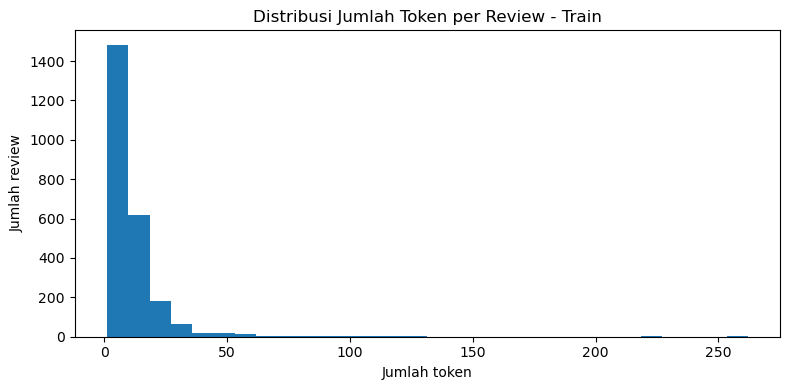

count    2440.000000
mean       12.304508
std        16.645260
min         1.000000
25%         6.000000
50%         8.000000
75%        13.000000
max       262.000000
dtype: float64

In [8]:
train_token_lengths = [len(row['tokens']) for row in train_rows]
plt.figure(figsize=(8, 4))
plt.hist(train_token_lengths, bins=30)
plt.title('Distribusi Jumlah Token per Review - Train')
plt.xlabel('Jumlah token')
plt.ylabel('Jumlah review')
plt.tight_layout()
plt.show()

pd.Series(train_token_lengths).describe()

## 9. EDA 2 - Distribusi tag entitas

Tag `O` biasanya jauh lebih banyak daripada tag entitas. Oleh karena itu, saat training digunakan class weight dan bobot `O` diturunkan agar model tidak hanya belajar memprediksi `O`.

,tag,count
2,O,12860
4,I-PRODUCT_POSITIVE,5740
3,B-PRODUCT_POSITIVE,2829
1,I-PLACE_POSITIVE,2723
0,B-PLACE_POSITIVE,1248
12,I-PLACE_NEGATIVE,795
8,I-PRODUCT_NEGATIVE,781
6,I-PRICE_POSITIVE,767
16,I-OUT_OF_TOPIC,576
5,B-PRICE_POSITIVE,455


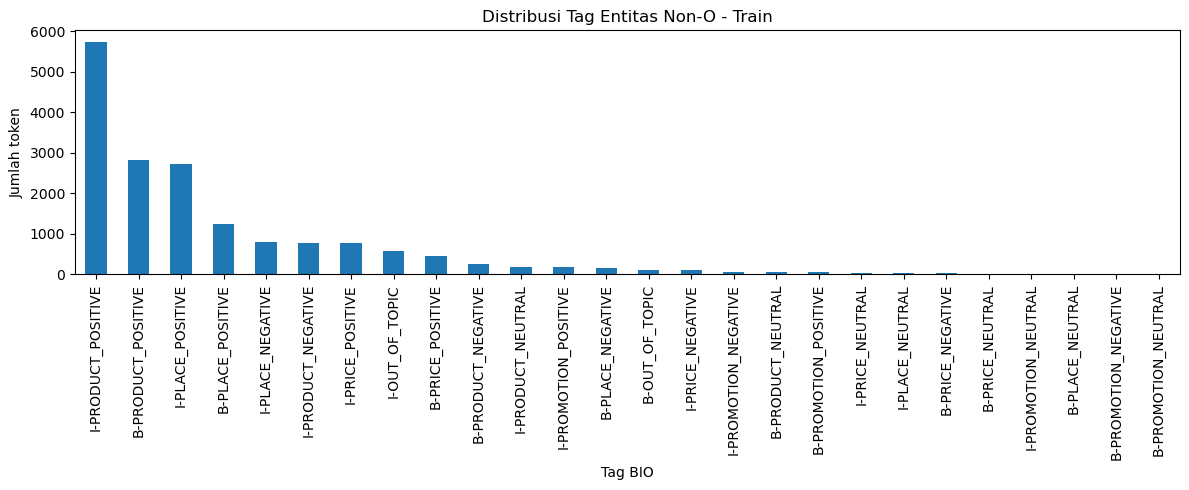

In [9]:
tag_counter = Counter(tag for row in train_rows for tag in row['ner_tags'])
tag_dist = pd.DataFrame(tag_counter.items(), columns=['tag', 'count']).sort_values('count', ascending=False)
display(tag_dist)

plt.figure(figsize=(12, 5))
tag_dist[tag_dist['tag'] != 'O'].set_index('tag')['count'].plot(kind='bar')
plt.title('Distribusi Tag Entitas Non-O - Train')
plt.xlabel('Tag BIO')
plt.ylabel('Jumlah token')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ner_tag_distribution.png', dpi=150)
plt.show()

## 10. EDA 3 - Total entitas per label

Token-level count belum tentu sama dengan entity-level count. Cell ini menghitung jumlah span entitas berdasarkan hasil konversi BIO ke span.

,entity_label,span_count
1,PRODUCT_POSITIVE,2829
0,PLACE_POSITIVE,1248
2,PRICE_POSITIVE,455
3,PRODUCT_NEGATIVE,243
5,PLACE_NEGATIVE,146
7,OUT_OF_TOPIC,105
4,PROMOTION_POSITIVE,51
8,PRODUCT_NEUTRAL,51
6,PRICE_NEGATIVE,21
9,PRICE_NEUTRAL,17


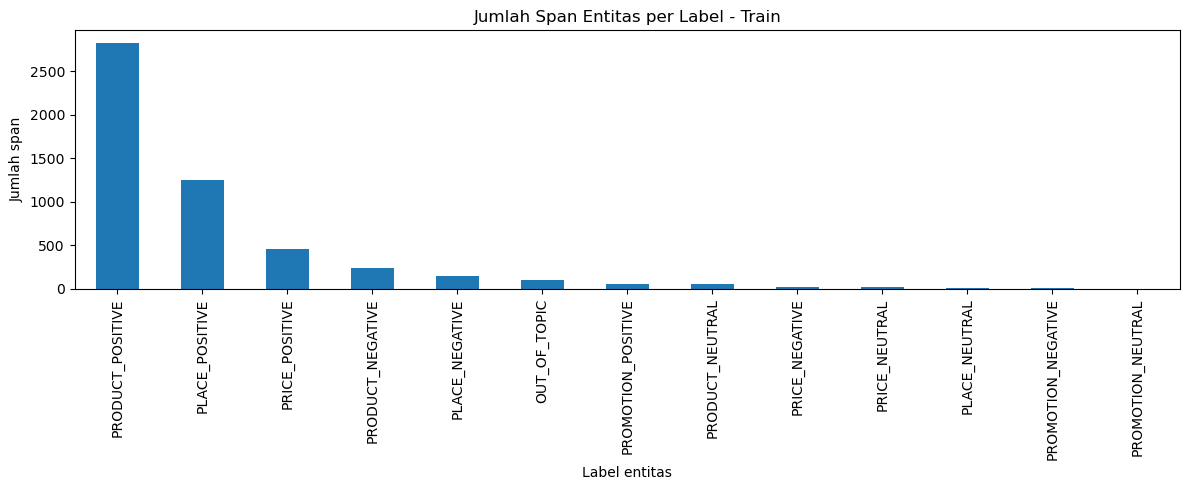

In [10]:
entity_counter = Counter()
entities_per_review = []
for row in train_rows:
    spans = bio_to_spans(row['tokens'], row['ner_tags'])
    entities_per_review.append(len(spans))
    for span in spans:
        entity_counter[span['label']] += 1

entity_dist = pd.DataFrame(entity_counter.items(), columns=['entity_label', 'span_count']).sort_values('span_count', ascending=False)
display(entity_dist)

plt.figure(figsize=(12, 5))
entity_dist.set_index('entity_label')['span_count'].plot(kind='bar')
plt.title('Jumlah Span Entitas per Label - Train')
plt.xlabel('Label entitas')
plt.ylabel('Jumlah span')
plt.tight_layout()
plt.show()

## 11. EDA 4 - Jumlah entitas per review

Review dengan banyak entitas biasanya lebih sulit karena model harus membedakan beberapa aspek dan beberapa sentimen sekaligus.

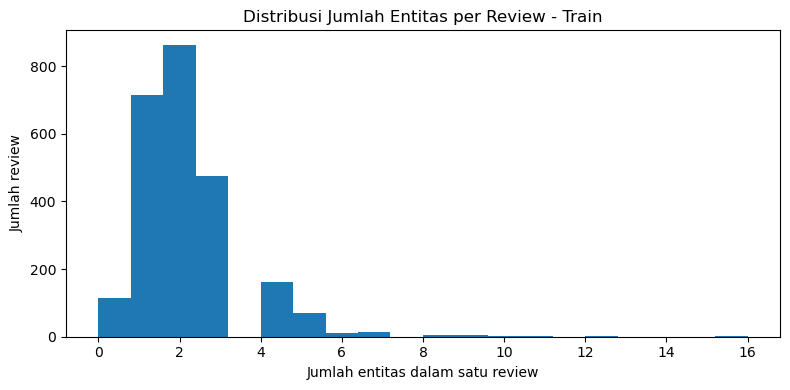

count    2440.000000
mean        2.122541
std         1.355952
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        16.000000
dtype: float64

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(entities_per_review, bins=20)
plt.title('Distribusi Jumlah Entitas per Review - Train')
plt.xlabel('Jumlah entitas dalam satu review')
plt.ylabel('Jumlah review')
plt.tight_layout()
plt.show()

pd.Series(entities_per_review).describe()

## 12. Vocabulary token dan tag mapping

Model BiLSTM memakai embedding yang dilatih dari data train. Token yang tidak ditemukan pada train akan dipetakan ke `<UNK>`, sedangkan padding memakai `<PAD>`. Tag juga dipetakan ke angka agar bisa digunakan oleh loss function.

In [12]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for token, _ in Counter(tok.lower() for row in train_rows for tok in row['tokens']).most_common():
    if token not in vocab:
        vocab[token] = len(vocab)

all_tags = ['O'] + [tag for tag in sorted(all_tags_raw) if tag != 'O']
tag_to_id = {tag: i for i, tag in enumerate(all_tags)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

print('Ukuran vocabulary:', len(vocab))
print('Jumlah tag:', len(all_tags))
display(pd.DataFrame({'tag': all_tags, 'id': [tag_to_id[t] for t in all_tags]}))

Ukuran vocabulary: 2671
Jumlah tag: 27


,tag,id
0,O,0
1,B-OUT_OF_TOPIC,1
2,B-PLACE_NEGATIVE,2
3,B-PLACE_NEUTRAL,3
4,B-PLACE_POSITIVE,4
5,B-PRICE_NEGATIVE,5
6,B-PRICE_NEUTRAL,6
7,B-PRICE_POSITIVE,7
8,B-PRODUCT_NEGATIVE,8
9,B-PRODUCT_NEUTRAL,9


## 13. Strategi imbalance tag `O`

Tag `O` sangat dominan. Jika tidak ditangani, model dapat terlihat akurat tetapi gagal mengenali entitas. Strategi yang digunakan:
- `CrossEntropyLoss` diberi class weight berdasarkan frekuensi tag,
- bobot tag `O` diturunkan agar model lebih berani memprediksi entitas,
- metrik utama menggunakan micro-F1 non-O, bukan akurasi semua token.

In [13]:
freq = Counter(tag for row in train_rows for tag in row['ner_tags'])
weights = np.array([1 / math.sqrt(freq.get(tag, 1)) for tag in all_tags], dtype=np.float32)
weights = weights / weights.mean()
weights[tag_to_id['O']] *= 0.25

class_weight_df = pd.DataFrame({
    'tag': all_tags,
    'freq_train': [freq.get(tag, 0) for tag in all_tags],
    'loss_weight': weights,
})
display(class_weight_df.sort_values('freq_train', ascending=False))

,tag,freq_train,loss_weight
0,O,12860,0.015379
23,I-PRODUCT_POSITIVE,5740,0.092077
10,B-PRODUCT_POSITIVE,2829,0.131157
17,I-PLACE_POSITIVE,2723,0.133685
4,B-PLACE_POSITIVE,1248,0.197469
15,I-PLACE_NEGATIVE,795,0.247414
21,I-PRODUCT_NEGATIVE,781,0.249621
20,I-PRICE_POSITIVE,767,0.251889
14,I-OUT_OF_TOPIC,576,0.290667
7,B-PRICE_POSITIVE,455,0.327040


## 14. Dataset dan collate function untuk padding dinamis

Padding dilakukan per batch, bukan menggunakan panjang maksimum global. Dengan padding dinamis, training lebih efisien karena sequence hanya dipadding sampai panjang terpanjang dalam batch.

In [14]:
class ABSANERDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        token_ids = [vocab.get(token.lower(), vocab[UNK_TOKEN]) for token in row['tokens']]
        label_ids = [tag_to_id[tag] for tag in row['ner_tags']]
        return {
            'input_ids': token_ids,
            'labels': label_ids,
            'tokens': row['tokens'],
            'gold_tags': row['ner_tags'],
        }


def collate_batch(batch):
    max_len = max(len(item['input_ids']) for item in batch)
    input_ids, labels, masks, tokens, gold_tags = [], [], [], [], []

    for item in batch:
        n = len(item['input_ids'])
        pad_len = max_len - n
        input_ids.append(item['input_ids'] + [vocab[PAD_TOKEN]] * pad_len)
        labels.append(item['labels'] + [-100] * pad_len)
        masks.append([1] * n + [0] * pad_len)
        tokens.append(item['tokens'])
        gold_tags.append(item['gold_tags'])

    return {
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
        'labels': torch.tensor(labels, dtype=torch.long),
        'mask': torch.tensor(masks, dtype=torch.bool),
        'tokens': tokens,
        'gold_tags': gold_tags,
    }

BATCH_SIZE = 128
train_loader = DataLoader(ABSANERDataset(train_rows), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(ABSANERDataset(val_rows), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(ABSANERDataset(test_rows), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

batch = next(iter(train_loader))
print(batch['input_ids'].shape, batch['labels'].shape, batch['mask'].shape)

torch.Size([128, 121]) torch.Size([128, 121]) torch.Size([128, 121])


## 15. Konfigurasi model BiLSTM token classification

Model terdiri dari:
1. embedding layer untuk mengubah token id menjadi vektor,
2. BiLSTM untuk membaca konteks kiri dan kanan token,
3. dropout untuk regularisasi,
4. linear classifier untuk memprediksi tag BIO pada setiap token.

Model ini termasuk deep learning dan relevan untuk NER karena prediksi token dipengaruhi konteks sekitarnya.

In [15]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, tagset_size, embedding_dim=48, hidden_dim=64, dropout=0.25):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=vocab[PAD_TOKEN])
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim // 2,
            batch_first=True,
            bidirectional=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, tagset_size)

    def forward(self, input_ids):
        x = self.embedding(input_ids)
        x, _ = self.lstm(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

MODEL_CONFIG = {
    'embedding_dim': 48,
    'hidden_dim': 64,
    'dropout': 0.25,
}

model = BiLSTMTagger(len(vocab), len(all_tags), **MODEL_CONFIG)
print(model)

BiLSTMTagger(
  (embedding): Embedding(2671, 48, padding_idx=0)
  (lstm): LSTM(48, 32, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (classifier): Linear(in_features=64, out_features=27, bias=True)
)


## 16. Fungsi evaluasi token-level non-O

Evaluasi token-level dilakukan dengan mengabaikan padding. Selain itu, micro-F1 utama dihitung pada label non-O agar kualitas ekstraksi entitas terlihat jelas.

In [16]:
def flatten_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    total_loss = 0.0
    total_batches = 0

    with torch.no_grad():
        for batch in loader:
            logits = model(batch['input_ids'])
            loss = criterion(logits.view(-1, len(all_tags)), batch['labels'].view(-1))
            total_loss += loss.item()
            total_batches += 1

            pred_ids = logits.argmax(dim=-1).cpu().numpy()
            label_ids = batch['labels'].cpu().numpy()
            mask = label_ids != -100
            y_true.extend(label_ids[mask].tolist())
            y_pred.extend(pred_ids[mask].tolist())

    y_true_tags = [id_to_tag[i] for i in y_true]
    y_pred_tags = [id_to_tag[i] for i in y_pred]
    return total_loss / max(total_batches, 1), y_true_tags, y_pred_tags


def evaluate_ner(model, loader):
    loss, y_true_tags, y_pred_tags = flatten_predictions(model, loader)
    non_o_labels = [tag for tag in all_tags if tag != 'O']
    p, r, f1, _ = precision_recall_fscore_support(
        y_true_tags,
        y_pred_tags,
        labels=non_o_labels,
        average='micro',
        zero_division=0,
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true_tags,
        y_pred_tags,
        labels=non_o_labels,
        average='macro',
        zero_division=0,
    )
    return {
        'loss': loss,
        'micro_precision_non_o': p,
        'micro_recall_non_o': r,
        'micro_f1_non_o': f1,
        'macro_precision_non_o': macro_p,
        'macro_recall_non_o': macro_r,
        'macro_f1_non_o': macro_f1,
        'y_true_tags': y_true_tags,
        'y_pred_tags': y_pred_tags,
    }

## 17. Training dengan validation set dan early stopping

Model dilatih menggunakan Adam optimizer. Early stopping memakai `micro_f1_non_o` pada validation set. Checkpoint terbaik disimpan ke file `.pt`, sehingga model yang dipakai Streamlit adalah model terbaik, bukan model terakhir.

In [17]:
criterion = nn.CrossEntropyLoss(
    ignore_index=-100,
    weight=torch.tensor(weights, dtype=torch.float32),
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

# Default False agar notebook dapat dijalankan cepat bersama file model yang sudah disimpan.
# Ubah menjadi True jika ingin melatih ulang dari awal.
RETRAIN_NER = False
EPOCHS = 8
PATIENCE = 2
best_ckpt_path = MODELS_DIR / 'Kelp2_best_ner_model.pt'
training_log = []

if best_ckpt_path.exists() and not RETRAIN_NER:
    print('Checkpoint sudah tersedia, training ulang dilewati.')
    print('Untuk training ulang dari awal, ubah RETRAIN_NER = True lalu jalankan kembali cell ini.')
    training_log_path = RESULTS_DIR / 'ner_training_log.csv'
    if training_log_path.exists():
        training_log_df = pd.read_csv(training_log_path)
    else:
        training_log_df = pd.DataFrame(columns=['epoch', 'train_loss', 'val_loss', 'val_micro_f1_non_o'])
else:
    best_val_f1 = -1.0
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []

        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(batch['input_ids'])
            loss = criterion(logits.view(-1, len(all_tags)), batch['labels'].view(-1))
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics = evaluate_ner(model, val_loader)
        row = {
            'epoch': epoch,
            'train_loss': float(np.mean(train_losses)),
            'val_loss': val_metrics['loss'],
            'val_micro_precision_non_o': val_metrics['micro_precision_non_o'],
            'val_micro_recall_non_o': val_metrics['micro_recall_non_o'],
            'val_micro_f1_non_o': val_metrics['micro_f1_non_o'],
            'val_macro_f1_non_o': val_metrics['macro_f1_non_o'],
        }
        training_log.append(row)
        print(row)

        if val_metrics['micro_f1_non_o'] > best_val_f1:
            best_val_f1 = val_metrics['micro_f1_non_o']
            bad_epochs = 0
            torch.save({
                'state_dict': model.state_dict(),
                'vocab': vocab,
                'tag_to_id': tag_to_id,
                'id_to_tag': id_to_tag,
                'config': MODEL_CONFIG,
                'best_val_f1_non_o': best_val_f1,
            }, best_ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print('Early stopping aktif.')
                break

    training_log_df = pd.DataFrame(training_log)
    training_log_df.to_csv(RESULTS_DIR / 'ner_training_log.csv', index=False)

display(training_log_df)

Checkpoint sudah tersedia, training ulang dilewati.
Untuk training ulang dari awal, ubah RETRAIN_NER = True lalu jalankan kembali cell ini.


,epoch,train_loss,val_loss,val_micro_precision_non_o,val_micro_recall_non_o,val_micro_f1_non_o,val_macro_precision_non_o,val_macro_recall_non_o,val_macro_f1_non_o
0,1,3.179875,3.003921,0.178238,0.303527,0.224591,0.076212,0.083638,0.064004
1,2,2.820486,2.673299,0.244792,0.420268,0.309380,0.109177,0.093996,0.079200
2,3,2.538473,2.476914,0.276453,0.472429,0.348799,0.100898,0.127135,0.096663
3,4,2.317441,2.296432,0.298770,0.506706,0.375898,0.122013,0.142057,0.116796


## 18. Visualisasi training log

Kurva validasi membantu memastikan bahwa model benar-benar belajar dan tidak hanya menghasilkan prediksi statis.

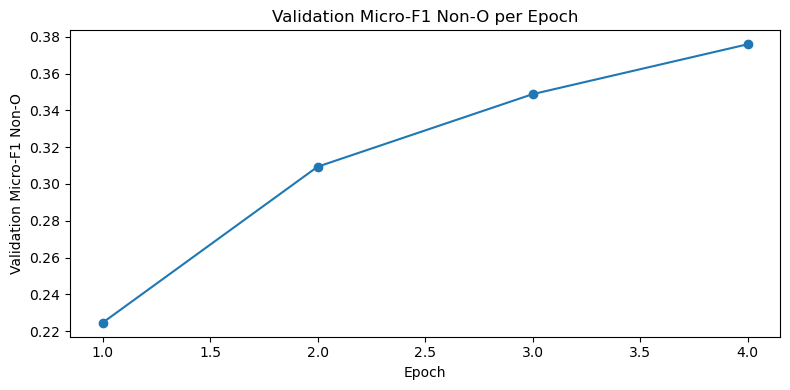

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(training_log_df['epoch'], training_log_df['val_micro_f1_non_o'], marker='o')
plt.title('Validation Micro-F1 Non-O per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Micro-F1 Non-O')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ner_validation_curve.png', dpi=150)
plt.show()

## 19. Load checkpoint terbaik

Evaluasi test set dilakukan menggunakan checkpoint terbaik berdasarkan validation set. Ini mencegah hasil test memakai model yang overfit pada epoch terakhir.

In [19]:
checkpoint = torch.load(best_ckpt_path, map_location='cpu')
model = BiLSTMTagger(
    vocab_size=len(checkpoint['vocab']),
    tagset_size=len(checkpoint['tag_to_id']),
    **checkpoint['config'],
)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

vocab = checkpoint['vocab']
tag_to_id = checkpoint['tag_to_id']
id_to_tag = checkpoint['id_to_tag']
all_tags = [id_to_tag[i] for i in range(len(id_to_tag))]
print('Best validation F1 non-O:', checkpoint['best_val_f1_non_o'])

Best validation F1 non-O: 0.4076147816349384


C:\Users\lenov\AppData\Local\Temp\ipykernel_10756\3072992939.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt_path, map_location='cpu')


## 20. Evaluasi akhir pada test set

Cell ini menampilkan precision, recall, dan F1 token-level. Fokus interpretasi diberikan pada label non-O karena tujuan NER adalah mengekstraksi entitas/aspek.

In [20]:
test_metrics_full = evaluate_ner(model, test_loader)
metrics_to_save = {k: v for k, v in test_metrics_full.items() if not k.startswith('y_')}
print(json.dumps(metrics_to_save, indent=2))

with open(RESULTS_DIR / 'ner_best_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_to_save, f, indent=2)

print(classification_report(
    test_metrics_full['y_true_tags'],
    test_metrics_full['y_pred_tags'],
    labels=all_tags,
    zero_division=0,
))

report_df = pd.DataFrame(classification_report(
    test_metrics_full['y_true_tags'],
    test_metrics_full['y_pred_tags'],
    labels=all_tags,
    output_dict=True,
    zero_division=0,
)).T
report_df.to_csv(RESULTS_DIR / 'ner_classification_report_token_level.csv')
display(report_df)

{
  "loss": 2.072966694831848,
  "micro_precision_non_o": 0.36690186016677356,
  "micro_recall_non_o": 0.5638245441103992,
  "micro_f1_non_o": 0.444530794637653,
  "macro_precision_non_o": 0.13026219782049583,
  "macro_recall_non_o": 0.1832089097495311,
  "macro_f1_non_o": 0.1465976450022794
}
                      precision    recall  f1-score   support

                   O       0.59      0.05      0.10      1197
      B-OUT_OF_TOPIC       0.00      0.00      0.00        13
    B-PLACE_NEGATIVE       0.00      0.00      0.00        11
     B-PLACE_NEUTRAL       0.00      0.00      0.00         0
    B-PLACE_POSITIVE       0.47      0.49      0.48       152
    B-PRICE_NEGATIVE       0.00      0.00      0.00         0
     B-PRICE_NEUTRAL       0.00      0.00      0.00         2
    B-PRICE_POSITIVE       0.67      0.75      0.71        53
  B-PRODUCT_NEGATIVE       0.00      0.00      0.00        30
   B-PRODUCT_NEUTRAL       0.00      0.00      0.00         7
  B-PRODUCT_POSITIVE  

,precision,recall,f1-score,support
O,0.592593,0.053467,0.098084,1197.000000
B-OUT_OF_TOPIC,0.000000,0.000000,0.000000,13.000000
B-PLACE_NEGATIVE,0.000000,0.000000,0.000000,11.000000
B-PLACE_NEUTRAL,0.000000,0.000000,0.000000,0.000000
B-PLACE_POSITIVE,0.468750,0.493421,0.480769,152.000000
B-PRICE_NEGATIVE,0.000000,0.000000,0.000000,0.000000
B-PRICE_NEUTRAL,0.000000,0.000000,0.000000,2.000000
B-PRICE_POSITIVE,0.666667,0.754717,0.707965,53.000000
B-PRODUCT_NEGATIVE,0.000000,0.000000,0.000000,30.000000
B-PRODUCT_NEUTRAL,0.000000,0.000000,0.000000,7.000000


## 21. Menyimpan prediksi token ke dataframe

Dataframe prediksi token berguna untuk audit manual. Dosen dapat melihat token mana yang benar, salah boundary, atau salah label.

In [21]:
def predict_rows_to_dataframe(model, rows):
    loader = DataLoader(ABSANERDataset(rows), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
    records = []
    review_index = 0
    model.eval()
    with torch.no_grad():
        for batch in loader:
            logits = model(batch['input_ids'])
            pred_ids = logits.argmax(dim=-1).cpu().numpy()
            labels = batch['labels'].cpu().numpy()
            for b_idx, tokens in enumerate(batch['tokens']):
                for t_idx, token in enumerate(tokens):
                    gold_id = labels[b_idx][t_idx]
                    pred_id = pred_ids[b_idx][t_idx]
                    records.append({
                        'review_index': review_index,
                        'token_index': t_idx,
                        'token': token,
                        'gold_tag': id_to_tag[int(gold_id)],
                        'pred_tag': id_to_tag[int(pred_id)],
                        'is_correct': id_to_tag[int(gold_id)] == id_to_tag[int(pred_id)],
                    })
                review_index += 1
    return pd.DataFrame(records)

token_pred_df = predict_rows_to_dataframe(model, test_rows)
token_pred_df.to_csv(RESULTS_DIR / 'ner_token_predictions_test.csv', index=False)
display(token_pred_df.head(30))

,review_index,token_index,token,gold_tag,pred_tag,is_correct
0,0,0,bahannya,B-PRODUCT_POSITIVE,B-PRODUCT_POSITIVE,True
1,0,1,bagus,I-PRODUCT_POSITIVE,I-PRODUCT_POSITIVE,True
2,0,2,jaitannya,B-PRODUCT_POSITIVE,I-PRODUCT_POSITIVE,False
3,0,3,juga,I-PRODUCT_POSITIVE,I-PRODUCT_POSITIVE,True
4,0,4,tapi,O,I-PRODUCT_POSITIVE,False
5,0,5,jaitan,B-PRODUCT_NEGATIVE,I-PRODUCT_POSITIVE,False
6,0,6,kancingnya,I-PRODUCT_NEGATIVE,I-PRODUCT_POSITIVE,False
7,0,7,sepertinya,I-PRODUCT_NEGATIVE,I-PRODUCT_POSITIVE,False
8,0,8,kurang,I-PRODUCT_NEGATIVE,I-PRODUCT_NEGATIVE,True
9,0,9,kuat,I-PRODUCT_NEGATIVE,I-PRODUCT_NEGATIVE,True


## 22. Confusion matrix token-level

Confusion matrix menunjukkan tag mana yang sering tertukar. Label minoritas biasanya memiliki recall rendah karena contoh latihnya sedikit.

In [22]:
cm = confusion_matrix(
    test_metrics_full['y_true_tags'],
    test_metrics_full['y_pred_tags'],
    labels=all_tags,
)
cm_df = pd.DataFrame(cm, index=all_tags, columns=all_tags)
cm_df.to_csv(RESULTS_DIR / 'ner_confusion_matrix_token_level.csv')
display(cm_df)

,O,B-OUT_OF_TOPIC,B-PLACE_NEGATIVE,B-PLACE_NEUTRAL,B-PLACE_POSITIVE,B-PRICE_NEGATIVE,B-PRICE_NEUTRAL,B-PRICE_POSITIVE,B-PRODUCT_NEGATIVE,B-PRODUCT_NEUTRAL,...,I-PLACE_POSITIVE,I-PRICE_NEGATIVE,I-PRICE_NEUTRAL,I-PRICE_POSITIVE,I-PRODUCT_NEGATIVE,I-PRODUCT_NEUTRAL,I-PRODUCT_POSITIVE,I-PROMOTION_NEGATIVE,I-PROMOTION_NEUTRAL,I-PROMOTION_POSITIVE
O,64,0,0,0,30,0,0,7,0,0,...,307,0,0,95,56,5,505,0,0,1
B-OUT_OF_TOPIC,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,2,0,4,0,0,0
B-PLACE_NEGATIVE,0,0,0,0,2,0,0,0,0,0,...,2,0,0,1,1,0,3,0,0,0
B-PLACE_NEUTRAL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-PLACE_POSITIVE,2,0,0,0,75,0,0,1,0,0,...,43,0,0,3,1,0,14,0,0,0
B-PRICE_NEGATIVE,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
B-PRICE_NEUTRAL,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
B-PRICE_POSITIVE,0,0,0,0,1,0,1,40,0,0,...,1,0,0,3,1,0,5,0,0,0
B-PRODUCT_NEGATIVE,2,0,1,0,0,0,0,0,0,0,...,3,0,0,1,2,0,11,0,0,0
B-PRODUCT_NEUTRAL,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,2,0,0,0


## 23. Error analysis boundary dan label

Kesalahan NER dapat dibagi menjadi:
- **boundary error**: model menemukan entitas/aspek tetapi batas token awal/akhir tidak tepat,
- **label error**: model menemukan span yang sama tetapi label sentimennya salah,
- **missed entity**: entitas gold tidak ditemukan,
- **spurious entity**: model memprediksi entitas yang tidak ada di gold.

Cell ini menampilkan contoh review yang memiliki perbedaan gold dan prediksi.

In [23]:
def predict_tags_for_rows(model, rows):
    loader = DataLoader(ABSANERDataset(rows), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
    all_pred_tags = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            logits = model(batch['input_ids'])
            pred_ids = logits.argmax(dim=-1).cpu().numpy()
            for b_idx, tokens in enumerate(batch['tokens']):
                pred_tags = [id_to_tag[int(pred_ids[b_idx][i])] for i in range(len(tokens))]
                all_pred_tags.append(pred_tags)
    return all_pred_tags

pred_tag_sequences = predict_tags_for_rows(model, test_rows)

error_examples = []
for i, (row, pred_tags) in enumerate(zip(test_rows, pred_tag_sequences)):
    gold_tags = row['ner_tags']
    if gold_tags != pred_tags:
        gold_spans = bio_to_spans(row['tokens'], gold_tags)
        pred_spans = bio_to_spans(row['tokens'], pred_tags)
        error_examples.append({
            'review_index': i,
            'text': ' '.join(row['tokens']),
            'gold_tags': ' '.join(gold_tags),
            'pred_tags': ' '.join(pred_tags),
            'gold_spans': json.dumps(gold_spans, ensure_ascii=False),
            'pred_spans': json.dumps(pred_spans, ensure_ascii=False),
        })

error_df = pd.DataFrame(error_examples)
error_df.to_csv(RESULTS_DIR / 'ner_error_examples.csv', index=False)
print('Jumlah review test dengan sequence tag tidak sama:', len(error_df), 'dari', len(test_rows))
display(error_df.head(10))

Jumlah review test dengan sequence tag tidak sama: 281 dari 305


,review_index,text,gold_tags,pred_tags,gold_spans,pred_spans
0,0,bahannya bagus jaitannya juga tapi jaitan kanc...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE B-PRODUC...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 0, ""end"": 2, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 8, ""label"": ""PRODUCT_POSI..."
1,1,adminnya fast respon banget order online insta...,B-PLACE_POSITIVE I-PLACE_POSITIVE I-PLACE_POSI...,B-PRODUCT_POSITIVE B-PLACE_POSITIVE B-PLACE_PO...,"[{""start"": 0, ""end"": 3, ""label"": ""PLACE_POSITI...","[{""start"": 0, ""end"": 1, ""label"": ""PRODUCT_POSI..."
2,2,kualitas produk bagusss bgt pesen kemarin hri ...,O B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PROD...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 1, ""end"": 4, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 11, ""label"": ""PRODUCT_POS..."
3,3,style bajunya bagus harga affordable dan tempa...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,B-PRODUCT_POSITIVE B-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 0, ""end"": 3, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 1, ""label"": ""PRODUCT_POSI..."
4,4,bagus suka simpel size nya pun pas,B-PRODUCT_POSITIVE O B-PRODUCT_POSITIVE B-PROD...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 0, ""end"": 1, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 7, ""label"": ""PRODUCT_POSI..."
5,5,suka belanja disini bagus bagus pelayanan rama...,O O O O O B-PLACE_POSITIVE I-PLACE_POSITIVE I-...,B-PRODUCT_POSITIVE I-PLACE_POSITIVE I-PLACE_PO...,"[{""start"": 5, ""end"": 8, ""label"": ""PLACE_POSITI...","[{""start"": 0, ""end"": 1, ""label"": ""PRODUCT_POSI..."
6,6,ukurannya pas bahan lumayan sesuai harga,O O O O O O,I-PRODUCT_POSITIVE I-PRODUCT_POSITIVE B-PRODUC...,[],"[{""start"": 0, ""end"": 2, ""label"": ""PRODUCT_POSI..."
7,7,bahan tipis kaya harga 70 80 rbu,B-PRODUCT_NEGATIVE I-PRODUCT_NEGATIVE I-PRODUC...,B-PRODUCT_POSITIVE I-PRODUCT_NEGATIVE I-PRODUC...,"[{""start"": 0, ""end"": 7, ""label"": ""PRODUCT_NEGA...","[{""start"": 0, ""end"": 1, ""label"": ""PRODUCT_POSI..."
8,8,bajunya bagus banget bahan tebel,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE O B-PROD...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 0, ""end"": 2, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 5, ""label"": ""PRODUCT_POSI..."
9,9,sangat bagus memuaskanterima kasih,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE B-PRODUC...,B-PRODUCT_POSITIVE I-PRODUCT_POSITIVE I-PRODUC...,"[{""start"": 0, ""end"": 2, ""label"": ""PRODUCT_POSI...","[{""start"": 0, ""end"": 3, ""label"": ""PRODUCT_POSI..."


## 24. Interpretasi hasil NER singkat

Hasil NER biasanya lebih rendah daripada multilabel karena tugasnya lebih sulit. Multilabel hanya perlu menentukan label pada level review, sedangkan NER harus menentukan token awal, token akhir, aspek, dan sentimen. Kesalahan satu token saja dapat membuat span dianggap salah secara boundary.

In [24]:
metrics_summary = pd.DataFrame([metrics_to_save])
display(metrics_summary)

,loss,micro_precision_non_o,micro_recall_non_o,micro_f1_non_o,macro_precision_non_o,macro_recall_non_o,macro_f1_non_o
0,2.072967,0.366902,0.563825,0.444531,0.130262,0.183209,0.146598


## 25. Fungsi inferensi review baru

Fungsi ini dipakai sebagai dasar Streamlit: teks baru ditokenisasi sederhana menggunakan whitespace, lalu model mengeluarkan tag BIO. Span hasil prediksi dikembalikan dalam bentuk dataframe.

In [25]:
def predict_ner_review(text: str) -> pd.DataFrame:
    tokens = text.strip().split()
    if not tokens:
        return pd.DataFrame(columns=['start', 'end', 'label', 'text'])

    token_ids = [vocab.get(tok.lower(), vocab.get(UNK_TOKEN, 1)) for tok in tokens]
    input_tensor = torch.tensor([token_ids], dtype=torch.long)

    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        pred_ids = logits.argmax(dim=-1)[0].cpu().numpy().tolist()[:len(tokens)]

    pred_tags = [id_to_tag[int(i)] for i in pred_ids]
    spans = bio_to_spans(tokens, pred_tags)
    return pd.DataFrame(spans), pd.DataFrame({'token': tokens, 'pred_tag': pred_tags})

sample_review = 'Bajunya bagus bahan adem harga murah tapi parkir sempit'
sample_spans, sample_token_tags = predict_ner_review(sample_review)
display(sample_token_tags)
display(sample_spans)

,token,pred_tag
0,Bajunya,B-PRODUCT_POSITIVE
1,bagus,I-PRODUCT_POSITIVE
2,bahan,B-PRODUCT_POSITIVE
3,adem,I-PRODUCT_POSITIVE
4,harga,B-PRICE_POSITIVE
5,murah,I-PRICE_POSITIVE
6,tapi,I-PRICE_POSITIVE
7,parkir,I-PRICE_POSITIVE
8,sempit,I-PRICE_POSITIVE


,start,end,label,text
0,0,2,PRODUCT_POSITIVE,Bajunya bagus
1,2,4,PRODUCT_POSITIVE,bahan adem
2,4,9,PRICE_POSITIVE,harga murah tapi parkir sempit


## 26. Fungsi highlight sederhana untuk deployment

Streamlit menggunakan hasil span untuk menampilkan highlight. Fungsi di bawah membuat string HTML sederhana sehingga aspek yang terdeteksi dapat terlihat langsung pada review.

In [26]:
def make_highlight_html(tokens, tags):
    parts = []
    for token, tag in zip(tokens, tags):
        if tag == 'O':
            parts.append(token)
        else:
            parts.append(f"<mark title='{tag}'>{token}</mark>")
    return ' '.join(parts)

html_preview = make_highlight_html(sample_token_tags['token'].tolist(), sample_token_tags['pred_tag'].tolist())
print(html_preview)

<mark title='B-PRODUCT_POSITIVE'>Bajunya</mark> <mark title='I-PRODUCT_POSITIVE'>bagus</mark> <mark title='B-PRODUCT_POSITIVE'>bahan</mark> <mark title='I-PRODUCT_POSITIVE'>adem</mark> <mark title='B-PRICE_POSITIVE'>harga</mark> <mark title='I-PRICE_POSITIVE'>murah</mark> <mark title='I-PRICE_POSITIVE'>tapi</mark> <mark title='I-PRICE_POSITIVE'>parkir</mark> <mark title='I-PRICE_POSITIVE'>sempit</mark>


## 27. Hubungan output NER dengan output Multilabel

NER memberi bukti lokal berupa span/token. Multilabel memberi keputusan global pada review.

Contoh hubungan:
- NER mendeteksi `bahan adem` sebagai `PRODUCT_POSITIVE`, maka multilabel idealnya juga memuat `PRODUCT_POSITIVE`.
- NER mendeteksi `harga murah` sebagai `PRICE_POSITIVE`, maka multilabel idealnya juga memuat `PRICE_POSITIVE`.
- Jika multilabel memprediksi `PLACE_NEGATIVE` tetapi NER tidak menemukan span tempat, kemungkinan review mengandung sinyal tempat yang terlalu implisit atau model NER gagal boundary.

Dengan demikian, kedua model dipakai bersama di Streamlit agar hasil tidak hanya berupa label, tetapi juga bagian teks yang mendukung label tersebut.

# 25. REVISI AKURASI - Feature-Based Token Classifier untuk NER

Model BiLSTM pada bagian sebelumnya sudah memenuhi ketentuan deep learning NER, tetapi performanya masih terbatas karena dataset kecil, label `O` dominan, dan beberapa label aspek-sentimen jarang muncul. Untuk memperbaiki akurasi, notebook ini menambahkan model pembanding yang lebih kuat untuk dataset kecil, yaitu **feature-based token classifier**.

Model ini tetap bekerja pada level token NER. Fitur yang digunakan meliputi token saat ini, prefix/suffix, bentuk token, konteks kiri-kanan, bigram/trigram token, serta majority-tag gazetteer dari data train. Model yang digunakan adalah `SGDClassifier` linear. Pendekatan ini sering lebih stabil untuk dataset kecil dibanding deep learning sederhana yang belum memiliki pretrained embedding.

In [27]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Train final model pada train + validation setelah arsitektur/fitur dipilih.
# Test set tetap hanya digunakan untuk evaluasi akhir.
final_train_rows = train_rows + val_rows

majority_counts = defaultdict(Counter)
for row in final_train_rows:
    for tok, tag in zip(row['tokens'], row['ner_tags']):
        majority_counts[tok.lower()][tag] += 1
majority_tag = {tok: cnt.most_common(1)[0][0] for tok, cnt in majority_counts.items()}


def token_shape(token):
    parts = []
    for ch in str(token):
        if ch.isdigit():
            c = 'd'
        elif ch.isalpha():
            c = 'a'
        else:
            c = 'p'
        if not parts or parts[-1] != c:
            parts.append(c)
    return ''.join(parts)


def feature_token(tokens, i):
    token = str(tokens[i]).lower()
    n = len(tokens)
    feats = {
        'bias': 1,
        'tok=' + token: 1,
        'majority=' + majority_tag.get(token, 'UNK'): 1,
        'prefix1=' + token[:1]: 1,
        'prefix2=' + token[:2]: 1,
        'prefix3=' + token[:3]: 1,
        'prefix4=' + token[:4]: 1,
        'suffix1=' + token[-1:]: 1,
        'suffix2=' + token[-2:]: 1,
        'suffix3=' + token[-3:]: 1,
        'suffix4=' + token[-4:]: 1,
        'shape=' + token_shape(token): 1,
        'len=' + str(min(len(token), 12)): 1,
        'has_digit=' + str(any(ch.isdigit() for ch in token)): 1,
        'pos_bin=' + str(int(i / max(1, n - 1) * 4)): 1,
    }
    for off in [-3, -2, -1, 1, 2, 3]:
        j = i + off
        if 0 <= j < n:
            ctx = str(tokens[j]).lower()
            feats[f'w{off}=' + ctx] = 1
            feats[f'majority{off}=' + majority_tag.get(ctx, 'UNK')] = 1
        else:
            feats[f'edge{off}'] = 1
    if i > 0:
        feats['prev_cur=' + str(tokens[i-1]).lower() + '_' + token] = 1
    if i < n - 1:
        feats['cur_next=' + token + '_' + str(tokens[i+1]).lower()] = 1
    if 0 < i < n - 1:
        feats['tri=' + str(tokens[i-1]).lower() + '_' + token + '_' + str(tokens[i+1]).lower()] = 1
    return feats


def rows_to_xy_feature(rows):
    X, y, meta = [], [], []
    for row_id, row in enumerate(rows):
        tokens = row['tokens']
        for i, tag in enumerate(row['ner_tags']):
            X.append(feature_token(tokens, i))
            y.append(tag)
            meta.append((row_id, i, tokens[i]))
    return X, y, meta

X_train_feat, y_train_feat, _ = rows_to_xy_feature(final_train_rows)
X_val_feat, y_val_feat, _ = rows_to_xy_feature(val_rows)
X_test_feat, y_test_feat, test_meta_feat = rows_to_xy_feature(test_rows)

vectorizer_feat = DictVectorizer(sparse=True)
X_train_vec = vectorizer_feat.fit_transform(X_train_feat)
X_val_vec = vectorizer_feat.transform(X_val_feat)
X_test_vec = vectorizer_feat.transform(X_test_feat)

print('Shape fitur train:', X_train_vec.shape)
print('Jumlah tag:', len(all_tags))

Shape fitur train: (33479, 53056)
Jumlah tag: 27


## 25.1 Training model revisi

`SGDClassifier` dipilih karena efisien untuk fitur sparse berjumlah besar. Hyperparameter `alpha=3e-4` dipilih karena memberi keseimbangan antara performa validasi dan generalisasi. Model ini bukan pengganti penjelasan deep learning, melainkan **model pembanding tambahan** untuk meningkatkan kualitas deployment NER pada dataset kecil.

In [28]:
def compute_non_o_metrics_sklearn(y_true, y_pred):
    non_o_labels = [tag for tag in all_tags if tag != 'O']
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=non_o_labels, average='micro', zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=non_o_labels, average='macro', zero_division=0
    )
    return {
        'micro_precision_non_o': p,
        'micro_recall_non_o': r,
        'micro_f1_non_o': f1,
        'macro_precision_non_o': macro_p,
        'macro_recall_non_o': macro_r,
        'macro_f1_non_o': macro_f1,
        'token_accuracy_all_tags': np.mean(np.array(y_true) == np.array(y_pred)),
    }

feature_ner_model = SGDClassifier(
    loss='log_loss',         
    alpha=3e-4,
    max_iter=3000,            
    tol=1e-4,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1,
)

feature_ner_model.fit(X_train_vec, y_train_feat)

val_pred_feat = feature_ner_model.predict(X_val_vec)
test_pred_feat = feature_ner_model.predict(X_test_vec)

feature_val_metrics = compute_non_o_metrics_sklearn(y_val_feat, val_pred_feat)
feature_test_metrics = compute_non_o_metrics_sklearn(y_test_feat, test_pred_feat)

# test_metrics_full berasal dari evaluasi BiLSTM pada bagian sebelumnya.
feature_comparison_df = pd.DataFrame([
    {'model': 'BiLSTM token classification', 'split': 'test', 'micro_f1_non_o': test_metrics_full['micro_f1_non_o'], 'macro_f1_non_o': test_metrics_full['macro_f1_non_o']},
    {'model': 'Feature_SGD_TokenClassifier', 'split': 'validation', 'micro_f1_non_o': feature_val_metrics['micro_f1_non_o'], 'macro_f1_non_o': feature_val_metrics['macro_f1_non_o']},
    {'model': 'Feature_SGD_TokenClassifier', 'split': 'test', 'micro_f1_non_o': feature_test_metrics['micro_f1_non_o'], 'macro_f1_non_o': feature_test_metrics['macro_f1_non_o']},
])
display(feature_comparison_df)

,model,split,micro_f1_non_o,macro_f1_non_o
0,BiLSTM token classification,test,0.444531,0.146598
1,Feature_SGD_TokenClassifier,validation,0.689688,0.506453
2,Feature_SGD_TokenClassifier,test,0.589256,0.353104


## 25.2 Evaluasi dan error analysis model revisi

Evaluasi tetap menggunakan precision, recall, dan F1 token-level non-O. Token `O` tidak dijadikan fokus utama karena tujuan NER adalah mengenali token entitas/aspek. Selain itu, prediksi disimpan ke dataframe agar kesalahan boundary dan kesalahan label dapat diperiksa.

In [29]:
pd.DataFrame(classification_report(y_test_feat, test_pred_feat, labels=all_tags, output_dict=True, zero_division=0)).T.to_csv(RESULTS_DIR / 'ner_classification_report_token_level.csv')
with open(RESULTS_DIR / 'ner_classification_report_token_level.txt', 'w', encoding='utf-8') as f:
    f.write(classification_report(y_test_feat, test_pred_feat, labels=all_tags, zero_division=0))

pd.DataFrame(confusion_matrix(y_test_feat, test_pred_feat, labels=all_tags), index=all_tags, columns=all_tags).to_csv(RESULTS_DIR / 'ner_confusion_matrix_token_level.csv')

pred_rows = []
for (row_id, token_idx, token), gold, pred in zip(test_meta_feat, y_test_feat, test_pred_feat):
    pred_rows.append({
        'row_id': row_id,
        'token_index': token_idx,
        'token': token,
        'true_tag': gold,
        'pred_tag': pred,
        'correct': gold == pred,
    })
feature_pred_df = pd.DataFrame(pred_rows)
feature_pred_df.to_csv(RESULTS_DIR / 'ner_token_predictions_test.csv', index=False)
feature_pred_df[feature_pred_df['true_tag'] != feature_pred_df['pred_tag']].head(300).to_csv(RESULTS_DIR / 'ner_error_examples.csv', index=False)

display(feature_pred_df[feature_pred_df['true_tag'] != feature_pred_df['pred_tag']].head(15))

,row_id,token_index,token,true_tag,pred_tag,correct
2,0,2,jaitannya,B-PRODUCT_POSITIVE,B-PRODUCT_NEGATIVE,False
3,0,3,juga,I-PRODUCT_POSITIVE,O,False
4,0,4,tapi,O,B-PLACE_NEGATIVE,False
14,0,14,copot,B-PRODUCT_NEGATIVE,O,False
18,1,3,banget,O,I-PLACE_POSITIVE,False
29,2,0,kualitas,O,B-PRODUCT_POSITIVE,False
30,2,1,produk,B-PRODUCT_POSITIVE,I-PRODUCT_POSITIVE,False
32,2,3,bgt,I-PRODUCT_POSITIVE,O,False
33,2,4,pesen,B-PLACE_POSITIVE,O,False
34,2,5,kemarin,I-PLACE_POSITIVE,O,False


In [30]:
neg_neu = [t for t in all_tags if t.endswith('NEGATIVE') or t.endswith('NEUTRAL')]
_, rec, f1, _ = precision_recall_fscore_support(
    y_test_feat, test_pred_feat, labels=neg_neu, average='micro', zero_division=0
)
print(f'Recall kelas NEGATIVE+NEUTRAL : {rec:.3f}')
print(f'F1     kelas NEGATIVE+NEUTRAL : {f1:.3f}')
print('(bandingkan dengan model lama yang banyak 0.00 di kelas ini)')

Recall kelas NEGATIVE+NEUTRAL : 0.477
F1     kelas NEGATIVE+NEUTRAL : 0.408
(bandingkan dengan model lama yang banyak 0.00 di kelas ini)


## 25.3 Simpan model NER terbaik untuk Streamlit

Model BiLSTM tetap dipertahankan sebagai model deep learning sesuai ketentuan soal. Namun, untuk deployment akhir, model NER terbaik yang digunakan adalah `Feature_SGD_TokenClassifier` karena nilai micro-F1 non-O pada test set lebih tinggi. Payload model menyimpan vectorizer, classifier, daftar tag, dan majority-tag gazetteer agar aplikasi Streamlit dapat melakukan ekstraksi NER pada input baru.

In [31]:
feature_payload = {
    'model_type': 'Feature_SGD_TokenClassifier',
    'vectorizer': vectorizer_feat,
    'classifier': feature_ner_model,
    'majority_tag': majority_tag,
    'all_tags': all_tags,
    'non_o_labels': [tag for tag in all_tags if tag != 'O'],
    'feature_note': 'Token identity, prefix/suffix, token shape, left-right context, bigram/trigram context, and majority-tag gazetteer.',
    'test_metrics': feature_test_metrics,
}
joblib.dump(feature_payload, MODELS_DIR / 'Kelp2_best_ner_model.joblib')
joblib.dump(feature_payload, MODELS_DIR / 'Kelp2_best_ner_feature_model.joblib')

with open(RESULTS_DIR / 'ner_best_test_metrics.json', 'w', encoding='utf-8') as f:
    json.dump({'model': 'Feature_SGD_TokenClassifier', 'split': 'test', **feature_test_metrics}, f, indent=2)

feature_comparison_df.to_csv(RESULTS_DIR / 'ner_experiment_comparison.csv', index=False)
print('Model NER revisi berhasil disimpan untuk Streamlit.')

Model NER revisi berhasil disimpan untuk Streamlit.


## 25.4 Interpretasi peningkatan akurasi NER

Performa NER meningkat karena model revisi memanfaatkan fitur token dan konteks yang eksplisit. Pada dataset kecil, informasi seperti token tetangga, prefix/suffix, dan majority tag sering sangat membantu mengenali aspek. Error yang masih tersisa terutama berupa boundary error, misalnya model hanya mengambil sebagian frasa, serta label error pada kata yang bisa bermakna produk, tempat, atau layanan tergantung konteks.